In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the TOI catalog
df = pd.read_csv('TOI_Mar2025_1pt5to4_R_detected_only.csv')

print(f"Total rows: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Total rows: 813

Columns: ['TOI', 'TIC', 'CDPP (ppm)', 'Stellar Radius', 'Stellar Temperature', 'Stellar Magnitude', 'True Radius (Earth Radii)', 'True Period (Days)', 'Detection', 'TLS Period', 'TLS SDE strongest', 'TLS SDE > 7 array', 'TLS Periods array', 'TLS Period Uncertainty', 'TLS Depth', 'TLS Rp/Rs', 'TLS FAP', 'TLS SNR', 'Alias Detection but high FAP', 'toi', 'id', 'tfopwg_disp', 'rastr', 'ra', 'decstr', 'dec', 'st_pmra', 'st_pmraerr1', 'st_pmraerr2', 'st_pmralim', 'st_pmdec', 'st_pmdecerr1', 'st_pmdecerr2', 'st_pmdeclim', 'pl_tranmid', 'pl_tranmiderr1', 'pl_tranmiderr2', 'pl_tranmidlim', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_trandurh', 'pl_trandurherr1', 'pl_trandurherr2', 'pl_trandurhlim', 'pl_trandep', 'pl_trandeperr1', 'pl_trandeperr2', 'pl_trandeplim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'st_tmag', 'st_tmagerr1', 'st

,TOI,TIC,CDPP (ppm),Stellar Radius,Stellar Temperature,Stellar Magnitude,True Radius (Earth Radii),True Period (Days),Detection,TLS Period,...,st_radlim,toi_created,rowupdate,cdpp_wrong_default_params,pl_perturbed,mst,rotation_period,rotation_power,n_points,cdpp_ppm
0,5165.01,TIC 349986198,786.41,0.87,4642.1,12.5389,3.30,3.5775,True,3.578275,...,0,2022-02-08 22:12:15,2025-02-24 12:03:31,3143.9821343664307 ppm,3.355316,0.740000,3.878544,0.004021,3415.0,786.411401
1,6940.01,TIC 421006834,2470.62,0.37,3338.0,12.5437,2.03,0.3053,True,0.610562,...,0,2024-02-29 23:27:38,2025-02-02 12:03:02,1419.949041956558 ppm,2.164841,0.360966,1.776985,0.005477,3271.0,2470.619744
2,6944.01,TIC 421005422,421.60,0.76,5181.1,10.7077,2.61,12.3028,True,6.155519,...,0,2024-02-29 23:27:39,2025-02-02 12:03:02,343.289105839217 ppm,2.719528,0.879000,10.957087,0.364390,1060.0,421.596487
3,5789.01,TIC 87216634,69.85,0.88,5132.0,6.5715,2.54,12.9256,True,12.931127,...,0,2022-09-22 22:56:08,2025-01-29 12:03:23,68.49362156645407 ppm,2.634532,0.870000,7.135727,0.025312,3571.0,69.853333
4,5319.01,TIC 246965431,715.82,0.48,3580.0,12.0828,3.75,4.0785,True,4.078477,...,0,2022-02-28 23:27:40,2025-01-24 12:04:09,879.3164720406457 ppm,3.506951,0.500000,4.814211,0.007700,2901.0,715.821283


In [3]:
# Filter for only PC (Planet Candidate) and CP (Confirmed Planet)
df_filtered = df[df['tfopwg_disp'].isin(['PC', 'CP', 'KP'])]
df_filtered = df_filtered[df_filtered['pl_rade'] >= 1.8]
df_filtered = df_filtered[df_filtered['pl_rade'] <= 4]
df_filtered = df_filtered[(df_filtered['pl_orbper'] > 0.6028) & (df_filtered['pl_orbper'] < 25.1)]





print(f"Original count: {len(df)}")
print(f"Filtered count (PC or CP or KP): {len(df_filtered)}")
print(f"\nDisposition value counts:")
print(df['tfopwg_disp'].value_counts())
print(f"\nFiltered disposition value counts:")
print(df_filtered['tfopwg_disp'].value_counts())

# Save the filtered dataframe to a new CSV file
df_filtered.to_csv('TOI_Mar2025_1pt5to4_R_detected_real_only.csv', index=False)
print(f"\nSaved filtered data to: TOI_Mar2025_1pt5to4_R_detected_real_only.csv")

Original count: 813
Filtered count (PC or CP or KP): 687

Disposition value counts:
tfopwg_disp
PC     579
CP     157
KP      50
APC     18
FA       9
Name: count, dtype: int64

Filtered disposition value counts:
tfopwg_disp
PC    512
CP    133
KP     42
Name: count, dtype: int64

Saved filtered data to: TOI_Mar2025_1pt5to4_R_detected_real_only.csv


In [4]:
df_filtered

# Load full TOI list
toi_full = pd.read_csv("TOI_2026.04.01_04.04.12.csv")
print(toi_full)
# Robust TIC column finder
def _find_tic_col(frame):
    candidates = ["tic", "TIC", "tic_id", "TIC ID", "TICID", "id", 'tid']
    lower_map = {c.lower(): c for c in frame.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    raise KeyError("Could not find a TIC column in the provided dataframe.")

# Normalize TIC IDs to numeric values for reliable matching
def _normalize_tic(series):
    return (
        series.astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype(float)
        .astype("Int64")
    )

tic_col_full = _find_tic_col(toi_full)
tic_col_filtered = _find_tic_col(df_filtered)

toi_full_tic = _normalize_tic(toi_full[tic_col_full])
filtered_tic = _normalize_tic(df_filtered[tic_col_filtered])

# TICs that host multiple TOIs in the full list
multi_tics = toi_full_tic.value_counts()
multi_tics = multi_tics[multi_tics > 1].index

# Planets in df_filtered that are in multi-planet systems
multi_planet_df = df_filtered.loc[filtered_tic.isin(multi_tics)].copy()
multi_planet_df["tic_norm"] = filtered_tic[filtered_tic.isin(multi_tics)].values

# Add full-list multiplicity per TIC for context
full_mult_map = toi_full_tic.value_counts()
multi_planet_df["n_tois_in_full_catalog"] = multi_planet_df["tic_norm"].map(full_mult_map)

print(f"Filtered planets in multi-planet systems: {len(multi_planet_df)}")
print(f"Unique multi-planet host TICs in filtered set: {multi_planet_df['tic_norm'].nunique()}")
multi_planet_df[["TOI", "TIC", "tic_norm", "n_tois_in_full_catalog", "tfopwg_disp"]].sort_values(
    ["tic_norm", "TOI"]
).head(20)

          toi        tid tfopwg_disp         rastr          ra         decstr  \
0     1000.01   50365310          FP  07h29m25.85s  112.357708  -12d41m45.46s   
1     1001.01   88863718          PC  08h10m19.31s  122.580465  -05d30m49.87s   
2     1002.01  124709665          FP  06h58m54.47s  104.726966  -10d34m49.64s   
3     1003.01  106997505          FP  07h22m14.39s  110.559945  -25d12m25.26s   
4     1004.01  238597883          FP  08h08m42.77s  122.178195  -48d48m10.12s   
...       ...        ...         ...           ...         ...            ...   
7908   995.01  317951248          FP  07h23m14.75s  110.811443  +05d33m46.26s   
7909   996.01  142918609          FP  07h57m23.99s  119.349948  -19d30m57.65s   
7910   997.01  341729521          FP  08h05m16.69s  121.319521  -59d34m47.27s   
7911   998.01   54390047          FP  07h53m16.69s  118.319555  -14d13m07.76s   
7912   999.01  341186896          FP  07h55m27.38s  118.864086  -58d13m19.42s   

            dec  st_pmra  s

,TOI,TIC,tic_norm,n_tois_in_full_catalog,tfopwg_disp
533,1027.01,TIC 20318757,20318757,3,PC
184,1027.02,TIC 20318757,20318757,3,PC
534,1027.03,TIC 20318757,20318757,3,PC
463,282.04,TIC 29781292,29781292,4,CP
327,431.01,TIC 31374837,31374837,2,CP
482,487.01,TIC 31852980,31852980,2,PC
289,218.02,TIC 32090583,32090583,2,PC
490,732.02,TIC 36724087,36724087,2,CP
122,711.01,TIC 38510224,38510224,2,PC
181,5788.01,TIC 42883782,42883782,2,PC


3000-3500: 1000 bootstrap samples, std = 0.1060
3500-4000: 1000 bootstrap samples, std = 0.0692
4000-4500: 1000 bootstrap samples, std = 0.0658
4500-5000: 1000 bootstrap samples, std = 0.0731
5000-5500: 1000 bootstrap samples, std = 0.0525
5500-6000: 1000 bootstrap samples, std = 0.0477
6000-6500: 1000 bootstrap samples, std = 0.0633
6500-7000: 1000 bootstrap samples, std = 0.1284

Mean Radius by Temperature Bin:
Teff_bin
3000-3500    2.568943
3500-4000    2.513671
4000-4500    2.848933
4500-5000    2.810855
5000-5500    2.882775
5500-6000    2.923581
6000-6500    2.911584
6500-7000    3.179918
Name: Rp_recalc_earth_rad, dtype: float64
Planets per bin:
Teff_bin
3000-3500     25
3500-4000     50
4000-4500     52
4500-5000     59
5000-5500     83
5500-6000    120
6000-6500     61
6500-7000     15
Name: count, dtype: int64
total planets


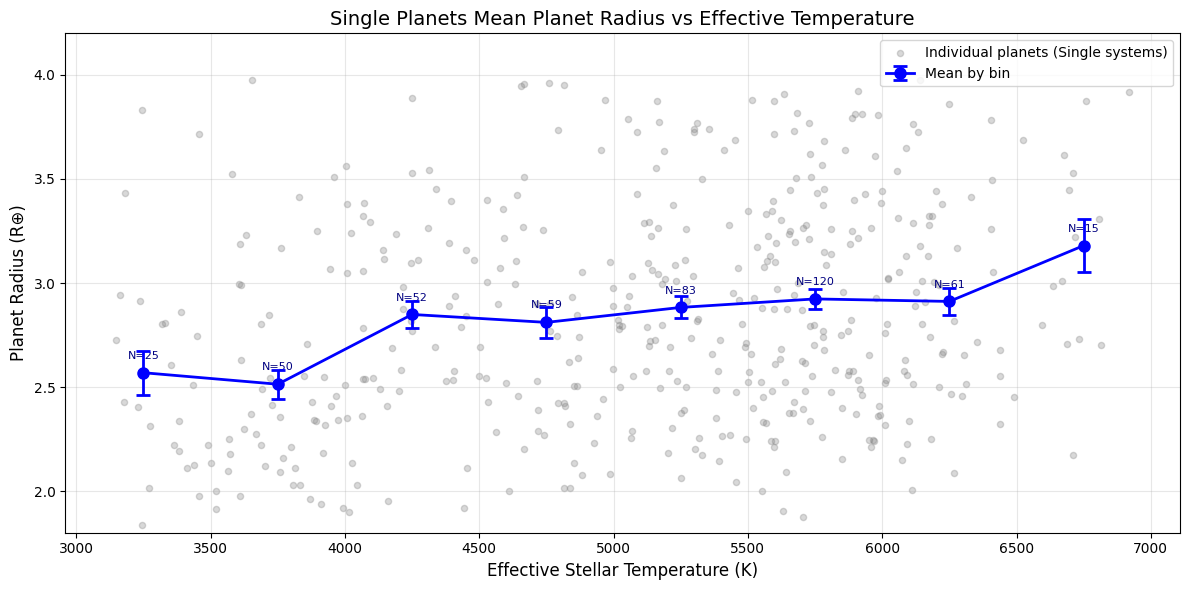

In [ ]:
# Create single_planet_df
single_planet_df = df_filtered.loc[~filtered_tic.isin(multi_tics)].copy()

# Ensure we use the correct column names for TEff, depth, radius
teff_col = 'st_teff' if 'st_teff' in single_planet_df.columns else ('Teff' if 'Teff' in single_planet_df.columns else None)
rad_col = 'st_rad' if 'st_rad' in single_planet_df.columns else ('Rad' if 'Rad' in single_planet_df.columns else None)
depth_col = 'pl_trandep' # usually pl_trandep

import matplotlib.pyplot as plt
import numpy as np

# Create temperature bins from 3000 to 7000K in 500K intervals
bins = np.arange(3000, 7001, 500)
bin_labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]

# Bin the data by stellar effective temperature
single_planet_df['Teff_bin'] = pd.cut(single_planet_df[teff_col], bins=bins, labels=bin_labels)

# Calculate mean radius for each temperature bin WHY DID I DO THIS??
transit_depths = single_planet_df[depth_col] #units of ppm
single_planet_df['pl_tranfrac'] = transit_depths / 1e6
single_planet_df['Rp_recalc_solar_rad'] = np.sqrt(single_planet_df['pl_tranfrac']) * single_planet_df[rad_col]
single_planet_df['Rp_recalc_earth_rad'] = single_planet_df['Rp_recalc_solar_rad'] * 109.1

merged_all_cut = single_planet_df[(single_planet_df['Rp_recalc_earth_rad'] <= 4) & (single_planet_df['Rp_recalc_earth_rad'] >= 1.8)]
merged_all_cut = merged_all_cut.dropna(subset=['Teff_bin', 'Rp_recalc_earth_rad'])

# Calculate bin centers for plotting the mean values
bin_centers = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]
mean_rad_by_teff = merged_all_cut.groupby('Teff_bin')['Rp_recalc_earth_rad'].mean()

# Bootstrap error bars
n_bootstrap = 1000
bootstrap_means = {bin_label: [] for bin_label in bin_labels}

for _ in range(n_bootstrap):
    # Resample with replacement
    resampled = merged_all_cut.sample(n=len(merged_all_cut), replace=True)
    # Calculate mean for each bin
    bin_means = resampled.groupby('Teff_bin')['Rp_recalc_earth_rad'].mean()
    for bin_label in bin_means.index:
        bootstrap_means[bin_label].append(bin_means[bin_label])

# Calculate standard errors from bootstrap distributions
std_errors_dict = {}
for bin_label in mean_rad_by_teff.index:
    if bin_label in bootstrap_means and len(bootstrap_means[bin_label]) > 0:
        std_errors_dict[bin_label] = np.std(bootstrap_means[bin_label])
        print(f"{bin_label}: {len(bootstrap_means[bin_label])} bootstrap samples, std = {std_errors_dict[bin_label]:.4f}")
    else:
        std_errors_dict[bin_label] = 0
        print(f"{bin_label}: No bootstrap samples!")

# Create aligned arrays for plotting
valid_bin_centers = [bin_centers[i] for i, label in enumerate(bin_labels) if label in mean_rad_by_teff.index]
valid_std_errors = [std_errors_dict[label] for label in mean_rad_by_teff.index]

fig, (ax_main) = plt.subplots(1, 1, figsize=(12, 6))

# Main scatter plot
ax_main.scatter(merged_all_cut[teff_col], merged_all_cut['Rp_recalc_earth_rad'], alpha=0.3, s=20, c='gray', label='Individual planets (Single systems)')
ax_main.errorbar(valid_bin_centers, mean_rad_by_teff.values, yerr=valid_std_errors, 
                 marker='o', linewidth=2, markersize=8, color='blue', 
                 label='Mean by bin', zorder=5, capsize=5, capthick=2)
ax_main.set_xlabel('Effective Stellar Temperature (K)', fontsize=12)
ax_main.set_ylabel('Planet Radius (R⊕)', fontsize=12)
ax_main.set_title('Single Planets Mean Planet Radius vs Effective Temperature', fontsize=14)
ax_main.legend()
ax_main.grid(True, alpha=0.3)
ax_main.set_ylim(1.8, 4.2)

# Print statistics
print("\nMean Radius by Temperature Bin:")
print(mean_rad_by_teff)
print(f'Planets per bin:')
print(merged_all_cut['Teff_bin'].value_counts().sort_index())
print('total planets')
# Add per-bin sample size labels
for x, bin_label in zip(valid_bin_centers, mean_rad_by_teff.index):
    n_in_bin = int((merged_all_cut["Teff_bin"] == bin_label).sum())
    y = mean_rad_by_teff.loc[bin_label]
    if np.isfinite(y):
        ax_main.annotate(
            f"N={n_in_bin}",
            (x, y),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="navy",
        )

plt.tight_layout()
plt.savefig("single_planet_mean_radius_vs_teff.png", dpi=300, bbox_inches="tight")
plt.show()